In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('base_final_narino_cundinamarca.csv')
data.head(5)

,Departamento,Municipio,Año,Área Cosechada,Área Sembrada,Producción,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),...,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,Rendimiento_lag1,Rendimiento_lag2,Rendimiento_lag3,Rendimiento_rolling3,Rendimiento_vs_media_mun
0,CUNDINAMARCA,ANAPOIMA,2008,234.66,244.87,104.030,0.443322,9397.211458,21.052603,21.534576,...,0.034885,0.288161,-0.041813,0.090587,753.137185,0.410887,NaN,NaN,0.410887,0.000000
1,CUNDINAMARCA,ANAPOIMA,2009,238.67,244.42,109.322,0.458047,7596.002594,21.659576,22.564850,...,-0.147636,-0.076189,-0.367224,-0.240564,753.137185,0.443322,0.410887,NaN,0.427104,0.016218
2,CUNDINAMARCA,ANAPOIMA,2010,244.25,251.16,114.100,0.467144,10091.935886,21.505259,23.381012,...,0.060390,0.094568,0.601869,0.299247,753.137185,0.458047,0.443322,0.410887,0.437418,0.020628
3,CUNDINAMARCA,ANAPOIMA,2011,245.00,247.00,116.000,0.473469,8696.465524,21.023651,21.647125,...,0.015540,0.021867,0.398428,0.166396,753.137185,0.467144,0.458047,0.443322,0.456171,0.022294
4,CUNDINAMARCA,ANAPOIMA,2012,107.00,107.00,53.500,0.500000,7848.365871,21.446869,21.943756,...,-0.069946,-0.136889,-0.022393,0.012682,753.137185,0.473469,0.467144,0.458047,0.466220,0.022896


In [3]:
data.columns

Index(['Departamento', 'Municipio', 'Año', 'Área Cosechada', 'Área Sembrada',
       'Producción', 'Rendimiento', 'Precipitación acumulada anual (mm/año)',
       'Temperatura media anual (°C)',
       'Máximo de la temperatura media mensual (°C)',
       'Mínimo de la temperatura media mensual (°C)',
       'Humedad relativa media anual (%)',
       'Radiación solar acumulada anual (MJ/m²/año)',
       'Humedad volumétrica media anual del suelo capa 1 (m³/m³)',
       'Humedad volumétrica media anual del suelo capa 2 (m³/m³)',
       'Evaporación potencial acumulada anual (mm/año)', 'SPI3_mean_anual',
       'SPI3_min_anual', 'SPI3_meses_bajo_m1', 'SPI6_mean_anual',
       'SPI6_min_anual', 'SPI6_meses_bajo_m1', 'SPI12_mean_anual',
       'SPI12_min_anual', 'SPI12_meses_bajo_m1', 'SPI3_dic', 'SPI6_dic',
       'SPI12_dic', 'SPI1_floracion', 'SPI3_floracion', 'SPI1_llenado',
       'SPI3_llenado', 'altitud_media_m', 'Rendimiento_lag1',
       'Rendimiento_lag2', 'Rendimiento_lag3', 'Re

# Selección de Variables

## Variables a eliminar

In [23]:
# Variables que se eliminan porque la variable y (Rendimiento) se calcula a partir de ellas:
var_calc_rdto = ['Área Cosechada', 'Área Sembrada', 'Producción']

# Variables que se eliminan porque son calculadas a partir de la variable y (Rendimiento):
var_rdtos = ['Rendimiento_rolling3','Rendimiento_vs_media_mun']

# Variables a eliminar porque generan colinealidad ya que vienen de la misma fuente:
var_spi = ['SPI3_mean_anual', 'SPI3_min_anual', 'SPI3_meses_bajo_m1', 'SPI6_mean_anual',
           'SPI6_min_anual', 'SPI6_meses_bajo_m1', 'SPI12_mean_anual', 'SPI12_min_anual',
           'SPI12_meses_bajo_m1', 'SPI3_dic', 'SPI6_dic', 'SPI1_floracion','SPI1_llenado']

## Variables a dejar

- **Identificadores y Controles:** `Departamento`, `Municipio`, `Año`, `altitud_media_m.`

- **Variables de Inercia:** `Rendimiento_lag1` (captura la salud previa del cultivo).

- **Bloque Hídrico (Críticas):** `SPI3_floracion`, `SPI3_llenado`, `SPI12_dic` (sequía acumulada).

- **Bloque Térmico:** `Máximo de la temperatura media mensual (°C)`, `Mínimo de la temperatura media mensual (°C).`

- **Suelo y Evaporación:** `Humedad volumétrica media anual del suelo capa 2`, `Evaporación potencial acumulada anual.`

In [27]:
vars_model = ['Departamento', 'Municipio', 'Año', 'altitud_media_m', 'Rendimiento_lag1', 'SPI3_floracion',
               'SPI3_llenado', 'SPI12_dic', 'Máximo de la temperatura media mensual (°C)',
               'Mínimo de la temperatura media mensual (°C)', 'Humedad volumétrica media anual del suelo capa 2 (m³/m³)', 
               'Evaporación potencial acumulada anual (mm/año)']

X = data[vars_model]
X.head(5)

,Departamento,Municipio,Año,altitud_media_m,Rendimiento_lag1,SPI3_floracion,SPI3_llenado,SPI12_dic,Máximo de la temperatura media mensual (°C),Mínimo de la temperatura media mensual (°C),Humedad volumétrica media anual del suelo capa 2 (m³/m³),Evaporación potencial acumulada anual (mm/año)
0,CUNDINAMARCA,ANAPOIMA,2008,753.137185,0.410887,0.288161,0.090587,0.990945,21.534576,20.717682,0.413769,1299.164296
1,CUNDINAMARCA,ANAPOIMA,2009,753.137185,0.443322,-0.076189,-0.240564,-0.561965,22.564850,21.122711,0.413046,1404.643724
2,CUNDINAMARCA,ANAPOIMA,2010,753.137185,0.458047,0.094568,0.299247,1.536935,23.381012,19.950592,0.412928,1287.480217
3,CUNDINAMARCA,ANAPOIMA,2011,753.137185,0.467144,0.021867,0.166396,0.412532,21.647125,20.361969,0.416187,1266.982543
4,CUNDINAMARCA,ANAPOIMA,2012,753.137185,0.473469,-0.136889,0.012682,-0.330545,21.943756,20.838287,0.412506,1385.323385


In [29]:
X.dtypes

Departamento                                                 object
Municipio                                                    object
Año                                                           int64
altitud_media_m                                             float64
Rendimiento_lag1                                            float64
SPI3_floracion                                              float64
SPI3_llenado                                                float64
SPI12_dic                                                   float64
Máximo de la temperatura media mensual (°C)                 float64
Mínimo de la temperatura media mensual (°C)                 float64
Humedad volumétrica media anual del suelo capa 2 (m³/m³)    float64
Evaporación potencial acumulada anual (mm/año)              float64
dtype: object

## Valdación de Colinealidad

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = X[X.columns[3:]]

# Calculo del  VIF para cada variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                             feature         VIF
6        Mínimo de la temperatura media mensual (°C)  802.414408
5        Máximo de la temperatura media mensual (°C)  800.258212
7  Humedad volumétrica media anual del suelo capa...  127.018831
0                                    altitud_media_m   27.469059
1                                   Rendimiento_lag1   10.992053
8     Evaporación potencial acumulada anual (mm/año)    6.592500
2                                     SPI3_floracion    4.375651
3                                       SPI3_llenado    3.220041
4                                          SPI12_dic    2.971144


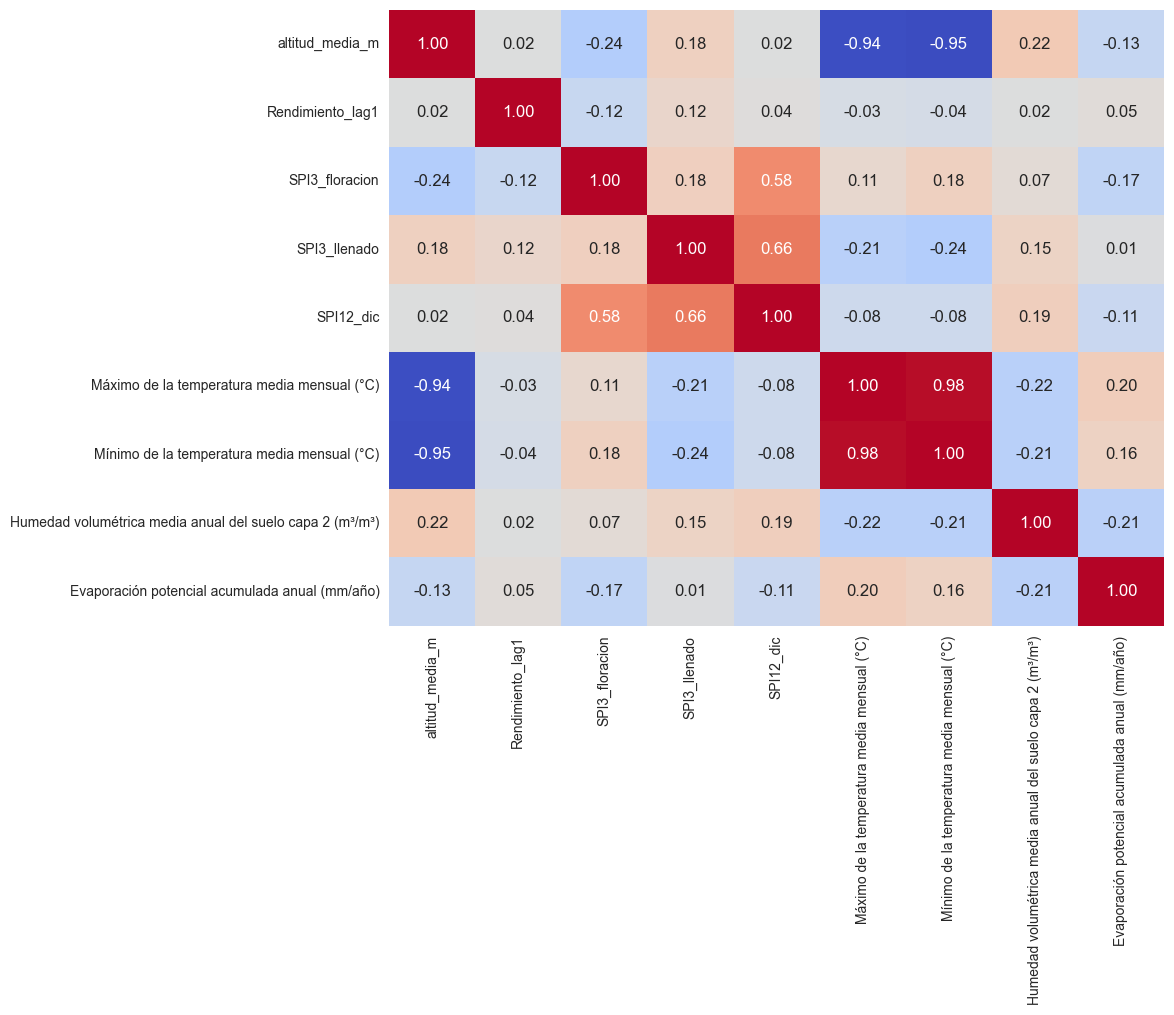

In [47]:
corr = X_num.corr()
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, cbar=False, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [48]:
# Se elimina la temperatura mínima esta correlacionada con la temperatura minima
# Se elimina la altitud porque también esta correlacionada con la temperatura (pisos termicos)

x_2 = X_num.drop(['Mínimo de la temperatura media mensual (°C)','altitud_media_m'], axis = 1)

vif_data = pd.DataFrame()
vif_data["feature"] = x_2.columns
vif_data["VIF"] = [variance_inflation_factor(x_2.values, i) for i in range(len(x_2.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                             feature        VIF
5  Humedad volumétrica media anual del suelo capa...  25.154664
4        Máximo de la temperatura media mensual (°C)  18.748242
0                                   Rendimiento_lag1  10.889534
6     Evaporación potencial acumulada anual (mm/año)   6.241864
1                                     SPI3_floracion   3.398609
2                                       SPI3_llenado   3.186880
3                                          SPI12_dic   2.879010


In [50]:
# Se elimina la humedad, que presenta un VIF de 25.2 (sigue metiendo ruido)
x_3 = x_2.drop(['Humedad volumétrica media anual del suelo capa 2 (m³/m³)'], axis = 1)

vif_data = pd.DataFrame()
vif_data["feature"] = x_3.columns
vif_data["VIF"] = [variance_inflation_factor(x_3.values, i) for i in range(len(x_3.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                          feature       VIF
4     Máximo de la temperatura media mensual (°C)  9.852085
0                                Rendimiento_lag1  8.721647
5  Evaporación potencial acumulada anual (mm/año)  6.218713
1                                  SPI3_floracion  3.305045
2                                    SPI3_llenado  3.090433
3                                       SPI12_dic  2.871579


# Comparación de modelos

In [109]:
cols_x = ['Departamento', 'Municipio', 'Año'] + x_3.columns.tolist()
cols_modelo = ['Rendimiento'] + cols_x 
data_modelo = data[cols_modelo]

data_modelo.head(5)

,Rendimiento,Departamento,Municipio,Año,Rendimiento_lag1,SPI3_floracion,SPI3_llenado,SPI12_dic,Máximo de la temperatura media mensual (°C),Evaporación potencial acumulada anual (mm/año)
0,0.443322,CUNDINAMARCA,ANAPOIMA,2008,0.410887,0.288161,0.090587,0.990945,21.534576,1299.164296
1,0.458047,CUNDINAMARCA,ANAPOIMA,2009,0.443322,-0.076189,-0.240564,-0.561965,22.564850,1404.643724
2,0.467144,CUNDINAMARCA,ANAPOIMA,2010,0.458047,0.094568,0.299247,1.536935,23.381012,1287.480217
3,0.473469,CUNDINAMARCA,ANAPOIMA,2011,0.467144,0.021867,0.166396,0.412532,21.647125,1266.982543
4,0.500000,CUNDINAMARCA,ANAPOIMA,2012,0.473469,-0.136889,0.012682,-0.330545,21.943756,1385.323385


In [4]:
# %pip install --upgrade numpy pandas pycaret
# %pip install shap

In [5]:
from pycaret.regression import *

In [60]:
exp = setup(
    data=data_modelo,
    target='Rendimiento',
    session_id=123,
    normalize=True,
    transformation=True
)

,Description,Value
0,Session id,123
1,Target,Rendimiento
2,Target type,Regression
3,Original data shape,"(1481, 10)"
4,Transformed data shape,"(1481, 10)"
5,Transformed train set shape,"(1036, 10)"
6,Transformed test set shape,"(445, 10)"
7,Numeric features,7
8,Categorical features,2
9,Preprocess,True


In [66]:
best_model = compare_models(include=['lr', 'lasso', 'ridge', 'dt'])

In [67]:
best_model

LinearRegression(n_jobs=-1)

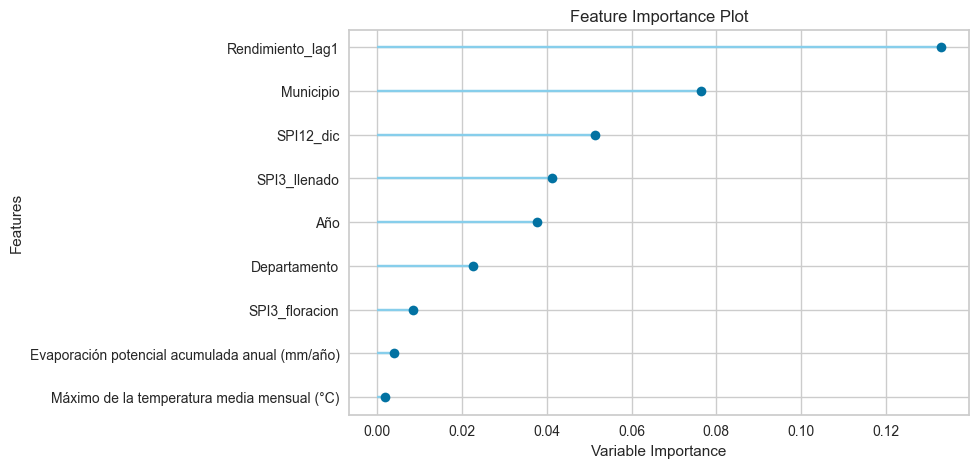

In [62]:
# 3. Analizar los modelos (clave para aseguradora)
plot_model(best_model, plot='feature')

In [9]:
# %pip install pycaret[analysis]
# %pip install interpret-community

In [69]:
# Interpretación tipo SHAP
interpret_model(best_model, plot='pfi')

9it [00:00, 81.87it/s]


In [64]:
interpret_model(best_model, plot='msa')

In [ ]:
# 4. Evaluación más profunda
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [71]:
lr_model = create_model('lr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1541,0.0396,0.1989,0.4770,0.1038,0.1864
1,0.1727,0.0648,0.2546,0.2130,0.1303,0.2418
2,0.1381,0.0322,0.1794,0.5171,0.0957,0.1602
3,0.1663,0.0470,0.2168,0.5212,0.1151,0.2169
4,0.1668,0.0598,0.2446,0.2897,0.1370,0.2966
5,0.1461,0.0400,0.2001,0.4380,0.1076,0.2041
6,0.1618,0.0479,0.2189,0.4068,0.1206,0.2634
7,0.1886,0.0645,0.2540,0.3456,0.1388,0.2951
8,0.1701,0.0532,0.2308,0.2006,0.1270,0.2541


In [72]:
tuned_lr = tune_model(lr_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1541,0.0396,0.1989,0.4770,0.1038,0.1864
1,0.1727,0.0648,0.2546,0.2130,0.1303,0.2418
2,0.1381,0.0322,0.1794,0.5171,0.0957,0.1602
3,0.1663,0.0470,0.2168,0.5212,0.1151,0.2169
4,0.1668,0.0598,0.2446,0.2897,0.1370,0.2966
5,0.1461,0.0400,0.2001,0.4380,0.1076,0.2041
6,0.1618,0.0479,0.2189,0.4068,0.1206,0.2634
7,0.1886,0.0645,0.2540,0.3456,0.1388,0.2951
8,0.1701,0.0532,0.2308,0.2006,0.1270,0.2541


Fitting 10 folds for each of 2 candidates, totalling 20 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


## Panel OLS

In [76]:
# %pip install linearmodels

In [97]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

In [110]:
# Se definen la variable dependiente e independientes
y = 'Rendimiento'
X = data_modelo.drop(['Rendimiento','Departamento','Municipio','Año'], axis=1).columns.tolist()

# Se hace la división de los datos entre train y test
data_train = data_modelo[data_modelo['Año'] <= 2021].copy()
data_test = data_modelo[data_modelo['Año'] >= 2022].copy()

# Se configuran los índices para PanelOLS
data_train = data_train.set_index(['Municipio', 'Año'])
data_test = data_test.set_index(['Municipio', 'Año'])

# Se generan los sets de train y test
y_train = data_train[y]
X_train = sm.add_constant(data_train[X])
y_test = data_test[y]
X_test = sm.add_constant(data_test[X])

In [111]:
# Se define el modelo
model = PanelOLS(y_train, X_train, entity_effects=True)
results = model.fit(cov_type='clustered', cluster_entity=True)

print("--- Resumen del Modelo (Train) ---")
print(results.summary)

--- Resumen del Modelo (Train) ---
                          PanelOLS Estimation Summary                           
Dep. Variable:            Rendimiento   R-squared:                        0.3067
Estimator:                   PanelOLS   R-squared (Between):             -1.0624
No. Observations:                1212   R-squared (Within):               0.3067
Date:                Fri, Apr 24 2026   R-squared (Overall):             -0.0375
Time:                        23:13:32   Log-likelihood                    218.29
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      82.146
Entities:                          92   P-value                           0.0000
Avg Obs:                       13.174   Distribution:                  F(6,1114)
Min Obs:                       2.0000                                           
Max Obs:                       14.000   F-statistic (robust):             

In [112]:
# Se Extraen los parámetros y efectos estimados
params = results.params
effects = results.estimated_effects.groupby(level='Municipio').first()

In [113]:
# Se predice usando el modelo 

pred_base = X_test.dot(params)
pred_final = pred_base + data_test.index.get_level_values('Municipio').map(effects.iloc[:, 0])

In [114]:
# Se evalua el desempeño
rmse = np.sqrt(mean_squared_error(y_test, pred_final))
r2_test = r2_score(y_test, pred_final)

print("\n--- Desempeño en Test (2022-2024) ---")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2_test:.4f}")


--- Desempeño en Test (2022-2024) ---
RMSE: 0.2858
R²: 0.2927


In [115]:
comparativa = pd.DataFrame({'Real': y_test, 'Predicho': pred_final})
print("\nPrimeras filas de la comparativa:")
print(comparativa.head())


Primeras filas de la comparativa:
                    Real  Predicho
Municipio Año                     
ANAPOIMA  2022  1.166099  0.761622
          2023  1.220102  0.959875
          2024  1.509883  0.969643
ANOLAIMA  2022  0.566234  0.747526
          2023  0.893740  0.751439


## Panel OLS con interacciones

In [116]:
# 1. Centrar las variables (restar la media) para evitar multicolinealidad inducida
data_modelo_2 = data_modelo.copy()
data_modelo_2['SPI3_fl_centered'] = data_modelo_2['SPI3_floracion'] - data_modelo_2['SPI3_floracion'].mean()
data_modelo_2['Tmax_centered'] = data_modelo_2['Máximo de la temperatura media mensual (°C)'] - data_modelo_2['Máximo de la temperatura media mensual (°C)'].mean()

# 2. Crear la variable de interacción
data_modelo_2['SPI_x_Tmax'] = data_modelo_2['SPI3_fl_centered'] * data_modelo_2['Tmax_centered']


y_2 = 'Rendimiento'
X_2 = data_modelo_2.drop(['Rendimiento','Departamento','Municipio','Año', 
                        'SPI3_fl_centered','Tmax_centered',], axis=1).columns.tolist()


# Se hace la división de los datos entre train y test
data_train_2 = data_modelo_2[data_modelo_2['Año'] <= 2021].copy()
data_test_2 = data_modelo_2[data_modelo_2['Año'] >= 2022].copy()

# Se configuran los índices para PanelOLS
data_train_2 = data_train_2.set_index(['Municipio', 'Año'])
data_test_2 = data_test_2.set_index(['Municipio', 'Año'])

# Se generan los sets de train y test
y_train_2 = data_train_2[y_2]
X_train_2 = sm.add_constant(data_train_2[X_2])
y_test_2 = data_test_2[y_2]
X_test_2 = sm.add_constant(data_test_2[X_2])

In [117]:
# Se define el modelo
model_2 = PanelOLS(y_train_2, X_train_2, entity_effects=True)
results_2 = model_2.fit(cov_type='clustered', cluster_entity=True)

print("--- Resumen del Modelo (Train) ---")
print(results_2.summary)

--- Resumen del Modelo (Train) ---
                          PanelOLS Estimation Summary                           
Dep. Variable:            Rendimiento   R-squared:                        0.3120
Estimator:                   PanelOLS   R-squared (Between):             -0.8578
No. Observations:                1212   R-squared (Within):               0.3120
Date:                Fri, Apr 24 2026   R-squared (Overall):              0.0142
Time:                        23:15:08   Log-likelihood                    222.93
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      72.109
Entities:                          92   P-value                           0.0000
Avg Obs:                       13.174   Distribution:                  F(7,1113)
Min Obs:                       2.0000                                           
Max Obs:                       14.000   F-statistic (robust):             

In [118]:
# Se Extraen los parámetros y efectos estimados
params_2 = results_2.params
effects_2 = results_2.estimated_effects.groupby(level='Municipio').first()

In [119]:
# Se predice usando el modelo 

pred_base_2 = X_test_2.dot(params_2)
pred_final_2 = pred_base_2 + data_test_2.index.get_level_values('Municipio').map(effects.iloc[:, 0])

In [120]:
# Se evalua el desempeño
rmse_2 = np.sqrt(mean_squared_error(y_test_2, pred_final_2))
r2_test_2 = r2_score(y_test_2, pred_final_2)

print("\n--- Desempeño en Test (2022-2024) ---")
print(f"RMSE: {rmse_2:.4f}")
print(f"R²: {r2_test_2:.4f}")


--- Desempeño en Test (2022-2024) ---
RMSE: 0.2899
R²: 0.2724


In [121]:
comparativa_2 = pd.DataFrame({'Real': y_test_2, 'Predicho': pred_final_2})
print("\nPrimeras filas de la comparativa:")
print(comparativa_2.head())


Primeras filas de la comparativa:
                    Real  Predicho
Municipio Año                     
ANAPOIMA  2022  1.166099  0.785843
          2023  1.220102  0.977512
          2024  1.509883  0.990615
ANOLAIMA  2022  0.566234  0.758397
          2023  0.893740  0.756210


## GAM

In [13]:
# %pip install pygam

In [14]:
from pygam import LinearGAM
from sklearn.base import BaseEstimator, RegressorMixin

class GAMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.model = LinearGAM()

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

In [15]:
from pycaret.regression import *

exp = setup(data=data, target='Rendimiento', session_id=123)

,Description,Value
0,Session id,123
1,Target,Rendimiento
2,Target type,Regression
3,Original data shape,"(1481, 38)"
4,Transformed data shape,"(1481, 38)"
5,Transformed train set shape,"(1036, 38)"
6,Transformed test set shape,"(445, 38)"
7,Numeric features,35
8,Categorical features,2
9,Rows with missing values,12.4%


In [16]:
gam = GAMRegressor()
gam_model = create_model(gam)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1023,0.0206,0.1434,0.7281,0.0788,0.1350
1,0.1202,0.0316,0.1777,0.6166,0.0880,0.1860
2,0.1077,0.0213,0.1459,0.6807,0.0791,0.1245
3,0.1152,0.0250,0.1581,0.7454,0.0896,0.1486
4,0.1545,0.0492,0.2218,0.4160,0.1219,0.2835
5,0.1104,0.0200,0.1415,0.7192,0.0779,0.1457
6,0.1180,0.0296,0.1721,0.6336,0.1009,0.2363
7,0.1359,0.0363,0.1906,0.6315,0.1080,0.2165
8,0.1120,0.0220,0.1482,0.6704,0.0819,0.1488


In [17]:
lr = create_model('lr')
rf = create_model('rf')
lasso = create_model('lasso')
ridge = create_model('ridge') 
dt = create_model('dt')

models = [lr, rf, lasso, ridge, dt, gam_model]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1447,0.0462,0.2150,0.3890,0.0985,0.1747
1,0.1518,0.0464,0.2154,0.4369,0.1054,0.1753
2,0.1196,0.0245,0.1567,0.6316,0.0840,0.1421
3,0.1385,0.0352,0.1875,0.6418,0.1007,0.1822
4,0.1512,0.0515,0.2269,0.3892,0.1317,0.2827
5,0.1286,0.0315,0.1775,0.5579,0.0965,0.1823
6,0.1560,0.0465,0.2157,0.4243,0.1213,0.2816
7,0.1561,0.0473,0.2175,0.5198,0.1205,0.2491
8,0.1491,0.0412,0.2029,0.3817,0.1148,0.2335


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1391,0.0360,0.1898,0.5239,0.1002,0.1751
1,0.1419,0.0503,0.2242,0.3898,0.1145,0.2009
2,0.1170,0.0267,0.1635,0.5989,0.0856,0.1308
3,0.1493,0.0410,0.2025,0.5824,0.1073,0.1917
4,0.1498,0.0512,0.2263,0.3925,0.1282,0.2696
5,0.1392,0.0397,0.1992,0.4429,0.1049,0.1861
6,0.1404,0.0387,0.1968,0.5209,0.1085,0.2356
7,0.1709,0.0568,0.2384,0.4232,0.1317,0.2752
8,0.1472,0.0476,0.2182,0.2850,0.1220,0.2341


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1656,0.0752,0.2742,0.0059,0.1257,0.2129
1,0.1645,0.0538,0.2319,0.3472,0.1109,0.1687
2,0.1553,0.0414,0.2035,0.3784,0.1088,0.2001
3,0.1766,0.0597,0.2442,0.3922,0.1278,0.2366
4,0.1767,0.0649,0.2548,0.2294,0.1491,0.3224
5,0.1452,0.0367,0.1916,0.4847,0.1038,0.2046
6,0.1663,0.0538,0.2320,0.3337,0.1290,0.3154
7,0.1907,0.0656,0.2561,0.3343,0.1407,0.3078
8,0.1580,0.0445,0.2108,0.3327,0.1222,0.2756


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1435,0.0495,0.2225,0.3454,0.0999,0.1734
1,0.1406,0.0422,0.2054,0.4876,0.1000,0.1609
2,0.1113,0.0212,0.1455,0.6821,0.0776,0.1321
3,0.1380,0.0360,0.1898,0.6329,0.1014,0.1806
4,0.1439,0.0479,0.2188,0.4320,0.1284,0.2746
5,0.1277,0.0301,0.1736,0.5773,0.0947,0.1799
6,0.1457,0.0424,0.2060,0.4749,0.1151,0.2593
7,0.1519,0.0462,0.2150,0.5310,0.1193,0.2469
8,0.1497,0.0411,0.2027,0.3829,0.1155,0.2393


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1921,0.0732,0.2706,0.0318,0.1424,0.2562
1,0.1844,0.0790,0.2811,0.0406,0.1518,0.2503
2,0.2085,0.0956,0.3092,-0.4344,0.1651,0.2326
3,0.2348,0.0925,0.3041,0.0578,0.1626,0.2987
4,0.1878,0.0657,0.2562,0.2208,0.1433,0.3058
5,0.1867,0.0683,0.2614,0.0410,0.1385,0.2414
6,0.2245,0.0927,0.3044,-0.1467,0.1689,0.3237
7,0.2219,0.0879,0.2965,0.1082,0.1602,0.3266
8,0.1954,0.0774,0.2782,-0.1622,0.1583,0.2793


In [18]:
# comparar métrcas

for m in models:
    print(m)
    print(pull())

LinearRegression(n_jobs=-1)
         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.1921  0.0732  0.2706  0.0318  0.1424  0.2562
1     0.1844  0.0790  0.2811  0.0406  0.1518  0.2503
2     0.2085  0.0956  0.3092 -0.4344  0.1651  0.2326
3     0.2348  0.0925  0.3041  0.0578  0.1626  0.2987
4     0.1878  0.0657  0.2562  0.2208  0.1433  0.3058
5     0.1867  0.0683  0.2614  0.0410  0.1385  0.2414
6     0.2245  0.0927  0.3044 -0.1467  0.1689  0.3237
7     0.2219  0.0879  0.2965  0.1082  0.1602  0.3266
8     0.1954  0.0774  0.2782 -0.1622  0.1583  0.2793
9     0.2187  0.0850  0.2916 -0.0718  0.1574  0.2894
Mean  0.2055  0.0817  0.2853 -0.0315  0.1548  0.2804
Std   0.0175  0.0101  0.0178  0.1732  0.0099  0.0322
RandomForestRegressor(n_jobs=-1, random_state=123)
         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.1921  0.0732  0.2706  0.0318  0.1424  0.2562
1     0.1844  0.0790

In [19]:
gam_model.model.plot()
plt.show()

AttributeError: 'LinearGAM' object has no attribute 'plot'

In [ ]:
# interracciones entre variables
from pygam import te

gam = LinearGAM(
    s(0) + s(1) + te(0,1)
)